In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyRTC.utils as utils
from pyRTC import *
from astropy.io import fits

Spinnaker python SDK installation not found
Spinnaker python SDK installation not found
ximea python SDK installation not found
PI python SDK installation not found


In [3]:
shm_names = ["wfs", "wfsRaw", "wfc", "wfc2D", "wfcShape", "signal", "signal2D", "psfShort", "psfLong", "wfsInfo", "loop", "refSlopes", "subApMasks", "cmat", "m2c"] #list of SHMs to reset
#shm_names = ["slopes", "signal2d"]
# for name in shm_names:
#     try:
#         # Suppress KeyError statements...
#         clear_shms([name])
#     except:
#         pass

clear_shms(shm_names)

Opening Existing Shared Memory Object wfs
Opening Existing Shared Memory Object wfs_meta
Opening Existing Shared Memory Object wfs_meta
Closing wfs
Creating New Shared Memory Object wfs_gpu_handle
Opening Existing Shared Memory Object wfs_gpu_handle_meta
Closing wfs_meta
Opening Existing Shared Memory Object wfsRaw
Opening Existing Shared Memory Object wfsRaw_meta
Closing wfs_gpu_handle
Opening Existing Shared Memory Object wfsRaw_meta
Closing wfsRaw
Creating New Shared Memory Object wfsRaw_gpu_handle
Opening Existing Shared Memory Object wfsRaw_gpu_handle_meta
Closing wfsRaw_meta
Opening Existing Shared Memory Object wfc
Opening Existing Shared Memory Object wfc_meta
Closing wfsRaw_gpu_handle
Opening Existing Shared Memory Object wfc_meta
Closing wfc
Creating New Shared Memory Object wfc_gpu_handle
Opening Existing Shared Memory Object wfc_gpu_handle_meta
Closing wfc_meta
Opening Existing Shared Memory Object wfc2D
Opening Existing Shared Memory Object wfc2D_meta
Closing wfc_gpu_handl

Traceback (most recent call last):
  File "/usr/lib64/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfs'
Traceback (most recent call last):
  File "/usr/lib64/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfs_meta'
Traceback (most recent call last):
  File "/usr/lib64/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfs_gpu_handle'
Traceback (most recent call last):
  File "/usr/lib64/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfsRaw'
Traceback (most recent call last):
  File "/usr/lib64/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].remove(name)
KeyError: '/wfsRaw_meta'
Traceback (most recent call last):
  File "/usr/lib64/python3.9/multiprocessing/resource_tracker.py", line 201, in main
    cache[rtype].r

### Use ICS

In [3]:
from gui.pyroics import get_ics_proxy

ics = get_ics_proxy()
print(ics.get_available_launchers())

['ImakaDM', 'IRTFASMSimulator', 'FELIXSimulator', 'AndorWFS', 'SlopesProcess', 'Loop', 'ImakaTelemetry']


In [4]:
ics.launch("ImakaDM")
ics.launch("AndorWFS")
ics.launch("SlopesProcess")
ics.launch("Loop")

0

In [5]:
ics.run("wfs", "start")
ics.run("wfc", "start")
ics.run("slopes", "start")
ics.run("loop", "start")

In [7]:
ics.shutdown_all()

In [6]:
ics.get("slopes", "xSubApOffset")

0

In [31]:
ics.set("wfs", "darkCount", 5)

0

In [3]:
ics.get_component_class("wfs")

'AndorWFS'

In [30]:
ics.run("wfs", "takeDark")

In [24]:
ics.run("wfs", "start")

In [33]:
ics.is_connected("wfs")

False

In [8]:
ics.shutdown_all()

In [7]:
ics.run("wfc", "flatten")
ics.run("wfs", "takeDark")

In [4]:
ics.set("slopes", "refSlopeCount", 500)

0

In [7]:
ics.set("slopes", "refSlopesFile", "/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/calib/felixcal/refSlopes_FELIX.npy")

0

In [5]:
ics.run("slopes", "takeRefSlopes")  # drops the frame rate?

In [9]:
ics.set("loop", "IMFile", "/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/calib/imat/imat.20260527.docrime.npy")

0

In [33]:
ics.set("loop", "pokeAmp", 0.4)
ics.set("loop", "numItersIM", 1200)

0

In [30]:
ics.run("wfc", "flatten")

In [26]:
ics.set("loop", "IMMethod", "docrime")

0

In [34]:
ics.run("loop", "computeIM")

In [35]:
ics.run("loop", "saveIM")

In [36]:
ics.run("loop", "start")

In [38]:
ics.run("loop", "setGain", 0.0)

In [16]:
coeffs = np.zeros(7)
coeffs[6] = 0.2
ics.run("loop", "sendToWfc", [0, 0, 0, 0, 0, 0, 0])

In [2]:
import Pyro5.errors
try:
    result = ics.launch("AndorWFS")
except Exception:
    print("Pyro traceback:")
    print("".join(Pyro5.errors.get_pyro_traceback()))


Pyro traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_67253/2146872779.py", line 3, in <module>
    result = ics.launch("AndorWFS")
  File "/usr/local/lib/python3.9/site-packages/Pyro5/client.py", line 510, in __call__
    return self.__send(self.__name, args, kwargs)
  File "/usr/local/lib/python3.9/site-packages/Pyro5/client.py", line 275, in _pyroInvoke
    raise data  # if you see this in your traceback, you should probably inspect the remote traceback as well
AttributeError: 'AndorWFS' object has no attribute 'roiLeft'
 +--- This exception occured remotely (Pyro) - Remote traceback:
 | Traceback (most recent call last):
 |   File "/usr/local/lib/python3.9/site-packages/Pyro5/server.py", line 481, in handleRequest
 |     data = method(*vargs, **kwargs)  # this is the actual method call to the Pyro object
 |   File "/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/gui/pyroics_soft.py", line 98, in launch
 |     instance = instantiate_component(component_class, hardware_clas

In [9]:
ics.shutdown("wfc")

0

### Manually open launchers

In [7]:
CONFIG_PATH = "/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/config"
PYRTC_CLASS_PATH = "/Users/ellenlee/Documents/pyRTC-IRTF/pyRTC"

with open(os.path.join(CONFIG_PATH, "ports.json")) as f:
    PORTS = json.load(f)

def check_config_and_make_launcher(hardware_class, config, port_name):
    # Need to explicilty check these files or the GUI will hang itself
    if not os.path.exists(hardware_class):
        raise FileNotFoundError(f"Hardware class file {hardware_class} not found.")
    if not os.path.exists(config):
        raise FileNotFoundError(f"Config file {config} not found.")
    return hardwareLauncher(hardware_class, config, port=PORTS[port_name])

def get_felixsim():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "FELIXsim.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfs_felixsim.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfs")
    return launcher

def get_andor():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "AndorWFS.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfs_andor.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfs")
    return launcher

def get_imakadm():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "ImakaDM.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfc.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfc")
    return launcher

def get_dmsim():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "hardware", "DMsim.py")
    config = os.path.join(CONFIG_PATH, "hrtc_wfcsim.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "wfc")
    return launcher

def get_slopes():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "SlopesProcess.py")
    config = os.path.join(CONFIG_PATH, "hrtc_slopes.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "slopes")
    return launcher

def get_loop():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "Loop.py")
    config = os.path.join(CONFIG_PATH, "hrtc_loop.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "loop")
    return launcher

def get_imakatel():
    hardware_class = os.path.join(PYRTC_CLASS_PATH, "ImakaTelemetry.py")
    config = os.path.join(CONFIG_PATH, "hrtc_tel.yaml")
    launcher = check_config_and_make_launcher(hardware_class, config, "tel")
    return launcher 


In [8]:
wfs = get_felixsim()
wfs.launch()
dm = get_dmsim()
dm.launch()
slopes = get_slopes()
slopes.launch()
loop = get_loop()
loop.launch()
tel = get_imakatel()
tel.launch()

Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/hardware/FELIXsim.py
Waiting for Process at 127.0.0.1:10489
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/hardware/DMsim.py
Waiting for Process at 127.0.0.1:10490
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/SlopesProcess.py
Waiting for Process at 127.0.0.1:10491
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/Loop.py
Waiting for Process at 127.0.0.1:10492
Connected
Launching Process: /Users/ellenlee/Documents/pyRTC-IRTF/pyRTC/ImakaTelemetry.py
Waiting for Process at 127.0.0.1:10493
Connected


True

In [11]:
wfs.run("start")

1

In [10]:
slopes.run("start")

1

In [9]:
loop.run("start")

1

In [17]:
slopes.setProperty("refSlopeCount", 70)
slopes.run("takeRefSlopes")

1

In [18]:
wfs.shutdown()
dm.shutdown()
slopes.shutdown()
loop.shutdown()
tel.shutdown()

1

In [ ]:
coeffs = np.zeros(7)
amp = 0.1
coeffs[0] = amp
#loop.run("sendToWfc", coeffs)
dm.run("sendToHardware", coeffs)

-1

In [ ]:
wfs = get_andor()
wfs.launch()

Launching Process: /home/felix/src/pyrtc/pyRTC-IRTF/pyRTC/hardware/AndorWFS.py
Waiting for Process at 127.0.0.1:10489
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...
Connection failed: [Errno 111] Connection refused
Retrying in 2 seconds...


Connected


In [25]:
wfs.run("stop")

1

### Soft RTC

In [2]:
basedir = "/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/config/"
#basedir = "/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/config/"

#conf = utils.read_yaml_file(basedir + "hrtc_wfs_felixsim.yaml")
conf = utils.read_yaml_file("/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/config/hrtc_wfs_andor.yaml")
wfs_conf = conf["wfs"]

conf = utils.read_yaml_file(basedir + "hrtc_slopes.yaml")
slopes_conf = conf["slopes"]

#conf = utils.read_yaml_file(basedir + "hrtc_wfcsim.yaml")
conf = utils.read_yaml_file(basedir + "hrtc_wfc.yaml")
dm_conf = conf["wfc"]

conf = utils.read_yaml_file(basedir + "hrtc_loop.yaml")
loop_conf = conf["loop"]

conf = utils.read_yaml_file(basedir + "hrtc_tel.yaml")
tel_conf = conf["tel"]

#wfs = FELIXSimulator(wfs_conf)
wfs = AndorWFS(wfs_conf)
#dm = IRTFASMSimulator(dm_conf)
dm = ImakaDM(dm_conf)
slopes = SlopesProcess(slopes_conf)
loop = Loop(loop_conf)
tel = ImakaTelemetry(tel_conf)

Creating New Shared Memory Object wfsRaw
Creating New Shared Memory Object wfsRaw_meta
Creating New Shared Memory Object wfs
Creating New Shared Memory Object wfs_meta
Thread expose: Priority set to REALTIME
Opening Existing Shared Memory Object wfsInfo
Opening Existing Shared Memory Object wfsInfo_meta
Using HSSpeed index 0: 17.00 MHz
Using VSSpeed index 1: 0.50 µs


Opening Existing Shared Memory Object wfc
Opening Existing Shared Memory Object wfc_meta
Thread sendToHardware: Priority set to REALTIME
Opening Existing Shared Memory Object m2c
Opening Existing Shared Memory Object m2c_meta
Connecting to loop CMD server...
Opening Existing Shared Memory Object wfc2D
Opening Existing Shared Memory Object wfc2D_meta
Opening Existing Shared Memory Object wfs_meta
Closing wfs_meta
Opening Existing Shared Memory Object wfs
Thread computeSignal: Priority set to REALTIME
Opening Existing Shared Memory Object wfs_meta
Creating New Shared Memory Object subApMasks
Creating New Shared Memory Object subApMasks_meta
Opening Existing Shared Memory Object signal
Opening Existing Shared Memory Object signal_meta
Opening Existing Shared Memory Object signal2D
Opening Existing Shared Memory Object signal2D_meta
Opening Existing Shared Memory Object refSlopes
Opening Existing Shared Memory Object refSlopes_meta
Opening Existing Shared Memory Object signal_meta
Closing 

In [3]:
wfs.start()
slopes.start()
dm.start()
loop.start()

In [4]:
slopes.ySubApOffset

0

In [390]:
tel.dataDir = "data/20260527/"
tel.setNumIter(20)

In [362]:
wfs.darkCount = 10
wfs.setExposure(0.5)
wfs.takeDark()

In [201]:
slopes.rotation = 50

In [382]:
slopes.makeSubApMasks(cx=1,cy=-6)

In [394]:
slopes.refSlopeCount = 20
slopes.takeRefSlopes()
ra_guide =  "19-50-34.73"
dec_guide = "+08-53-02.0"
slopes.refSlopesFile = f"calib/refSlopes/20260527_altair/{ra_guide}_{dec_guide}"
slopes.saveRefSlopes()

In [393]:
tel.save(0, saveWFSImages=True)

Opening Existing Shared Memory Object wfs_meta
Closing wfs_meta
Opening Existing Shared Memory Object wfs
Opening Existing Shared Memory Object wfs_meta
Opening Existing Shared Memory Object wfsRaw_meta
Closing wfsRaw_meta
Opening Existing Shared Memory Object wfsRaw
Opening Existing Shared Memory Object wfsRaw_meta
Opening Existing Shared Memory Object signal_meta
Closing signal_meta
Opening Existing Shared Memory Object signal
Opening Existing Shared Memory Object signal_meta
Opening Existing Shared Memory Object wfc2D_meta
Closing wfc2D_meta
Opening Existing Shared Memory Object wfc2D
Opening Existing Shared Memory Object wfc2D_meta
Opening Existing Shared Memory Object m2c_meta
Closing m2c_meta
Opening Existing Shared Memory Object m2c
Opening Existing Shared Memory Object m2c_meta
Opening Existing Shared Memory Object loop_meta
Closing loop_meta
Opening Existing Shared Memory Object loop
Opening Existing Shared Memory Object loop_meta
Opening Existing Shared Memory Object cmat_met

'/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/data/20260527/aocb0000.fits'

In [204]:
loop.pokeAmp = 0.25
loop.numItersIM = 1400

In [206]:
loop.IMMethod = "docrime"

In [207]:
loop.computeIM()
dm.flatten()

In [8]:
coeffs = np.zeros(7)
coeffs[6] = 0.4
loop.sendToWfc(coeffs)

In [388]:
loop.setGain(0.)
loop.leakyGain = 0.0

In [389]:
dm.flatten()

In [97]:
slopes.loadRefSlopes()

In [53]:
slopes.refSlopes

array([[ -9.30677  ,  12.415762 ],
       [-11.157588 ,  12.218365 ],
       [-13.76879  , -12.2627735],
       [  6.6570396,   8.312728 ]], dtype=float32)

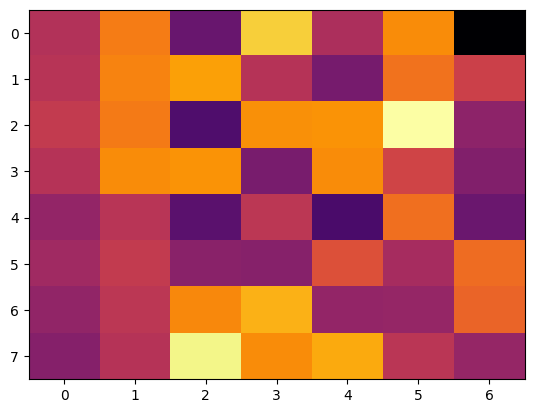

In [342]:
loop.plotIM()

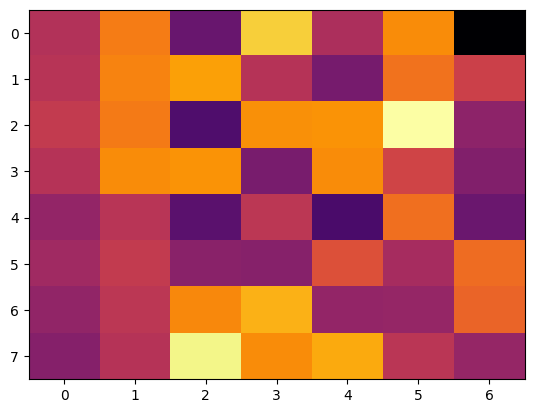

In [386]:
#loop.loadIM("/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/calib/imat/imat.20260527.docrime.npy")
loop.loadIM("/home/felix/src/pyrtc/pyRTC-IRTF/IRTF/calib/imat/imat.poke.20251002.c.npy")
loop.plotIM()

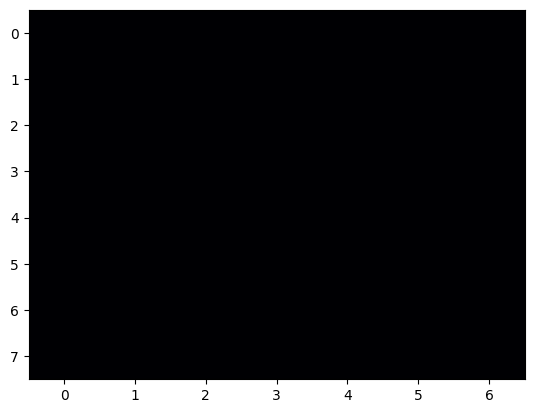

In [9]:
loop.plotIM()

In [19]:
imattheor = np.load("/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/calib/imat/felix_theor_imat_cmds.npy")
m2c = np.load("/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/calib/z2a.20240409b.7modes.npy")

In [23]:
imat = imattheor @ m2c

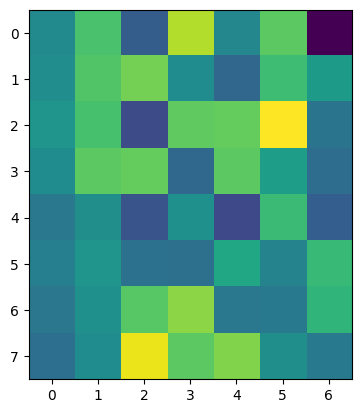

In [20]:
imat = np.load("/Users/ellenlee/Documents/pyRTC-IRTF/IRTF/calib/imat/imat.poke.20251002.c.npy")
plt.figure()
plt.imshow(imat)
plt.show()

In [24]:
imat.shape

(8, 7)

#### ncpa

In [368]:
from gui.gui_utils import calc_ncpa_lookup, angular_separation

def calc_ncpa_lookup(ra_target, dec_target, ra_guide, dec_guide, ncpa_lookup_file):
    """Calculate NCPA lookup table values.

    Returns
    -------
    ncpa : np.ndarray
        Array of NCPA values for each mode.
    dist_as : float
        Angular separation between target and guide star in arcseconds.
    """
    dist_as = angular_separation(ra_target, dec_target, ra_guide, dec_guide)
    ncpa_lookup = np.load(ncpa_lookup_file)

    n_modes = 7
    ncpa = np.zeros(n_modes, dtype=float)

    for i in range(n_modes):
        a = ncpa_lookup[i,0]
        b = ncpa_lookup[i,1]
        c = ncpa_lookup[i,2]
        #c = 0 # force center to be = 0
        parabola = lambda x: a * (x**2) + b*x +c
        ncpa[i] = parabola(dist_as)

    return ncpa, dist_as
    
ncpa_file = "calib/ncpa_model_7modes.npy"

ra_target = "19:50:47.00"
dec_target = "+08:52:06.0"
ra_guide =  "19:50:34.73"
dec_guide = "+08:53:02.0"
ncpa_coeffs, dist_as = calc_ncpa_lookup(ra_target, dec_target, ra_guide, dec_guide, ncpa_file)
print(dist_as)

190.27327722826166


In [369]:
imat = np.copy(loop.IM)
cmat = np.copy(loop.CM)
imat.shape

(8, 7)

In [370]:
lookupRefSlopes = imat @ ncpa_coeffs
print(ncpa_coeffs)
lookupRefSlopes = np.reshape(lookupRefSlopes, (4,2))

[0.         0.         2.72507062 0.         0.         0.
 0.        ]


In [371]:
lookupRefSlopes

array([[-12.14085602,   9.34673514],
       [-14.75752295,   8.18299342],
       [-13.49016719,  -8.46773421],
       [  7.0845317 ,  17.13974425]])

In [372]:
#oldRefSlopes = slopes.refSlopes.copy()
oldCoeffs = cmat @ oldRefSlopes.flatten()
print(oldRefSlopes)
print(oldCoeffs)

[[-11.050932  11.950879]
 [-12.277639  11.594662]
 [-13.225011 -11.142139]
 [  8.724882  10.259488]]
[ 0.10741949  1.6607544   2.5358696   0.11174741 -0.40609455 -0.14653146
  0.31020325]


In [351]:
testCoeffs = oldCoeffs.copy()
testCoeffs[:2] = 0
testCoeffs[3:] = 0
testCoeffs

array([0.       , 0.       , 2.5358696, 0.       , 0.       , 0.       ,
       0.       ], dtype=float32)

In [373]:
slopes.refSlopes = np.reshape( imat @ testCoeffs , (4,2) )

In [303]:
slopes.refSlopes = lookupRefSlopes

In [378]:
slopes.refSlopes = oldRefSlopes

In [317]:
oldRefSlopes

array([[-10.327399,  12.349455],
       [-13.755118,   9.859696],
       [-13.984613,  -9.358179],
       [  8.177567,  11.799712]], dtype=float32)

In [325]:
slopes.refSlopes

array([[-11.204662 ,   8.6259985],
       [-13.619555 ,   7.5519943],
       [-12.449926 ,  -7.8147783],
       [  6.538236 ,  15.818081 ]], dtype=float32)

In [379]:
dm.flatten()

In [381]:
loop.setGain(0.)
loop.leakyGain = 0.0

shutdown

In [5]:
wfs.shutdown()
for component in [loop, slopes, dm, wfs, tel]:
    try:
        del component
    except:
        pass

### Debug Andor SDK

In [34]:
from pyAndorSDK2 import atmcd, atmcd_codes, atmcd_errors
sdk = atmcd()
sdk.Initialize("/usr/local/etc/andor/")
sdk.SetAcquisitionMode(atmcd_codes.Acquisition_Mode.SINGLE_SCAN)

20075

In [7]:
sdk.GetNumberVSSpeeds()

(20002, 5)

In [3]:
sdk.ShutDown()

20002

In [47]:
binning = 2
left = 1
top = 1
width = 512
height = 512
size = int( width * height / (binning*binning) )

sdk.SetImage(
        hbin   = binning,
        vbin   = binning,
        hstart = left,
        hend   = left + width - 1,
        vstart = top,
        vend   = top + height - 1
    )

20002

In [54]:
sdk.AbortAcquisition()

20002

In [48]:
sdk.StartAcquisition()

20002

In [49]:
size

65536

In [50]:
ret, raw = sdk.GetMostRecentImage16(size)
raw = np.array(raw, copy=True)

In [52]:
imout = raw.reshape((height//binning, width//binning))

In [53]:
imout.min()


346

In [55]:
sdk.ShutDown()

20002